# Figures 4, 10, and 11: ADR PDE Experiment Results

**Figure 4** — M-CaStLe angle estimation error as a function of diffusion coefficient (left) and advection velocity (right). Each panel shows mean and median with 95% CI; green line shows proportion of trials with error > 45°.

**Figure 10** — Ground-truth reaction graph for the two-species ADR experiment.

**Figure 11** — Distribution of reaction-graph F1 scores across all ADR parameter combinations.

**Data required:**  
- `../data/figures/angle_error2_data.csv` — ADR angle estimation results  
- `../data/figures/adr_reaction_f1_data.csv` — ADR reaction-graph F1 scores

Figures are saved to `figures/` relative to this notebook.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

## Figure 4: ADR Angle Estimation Error

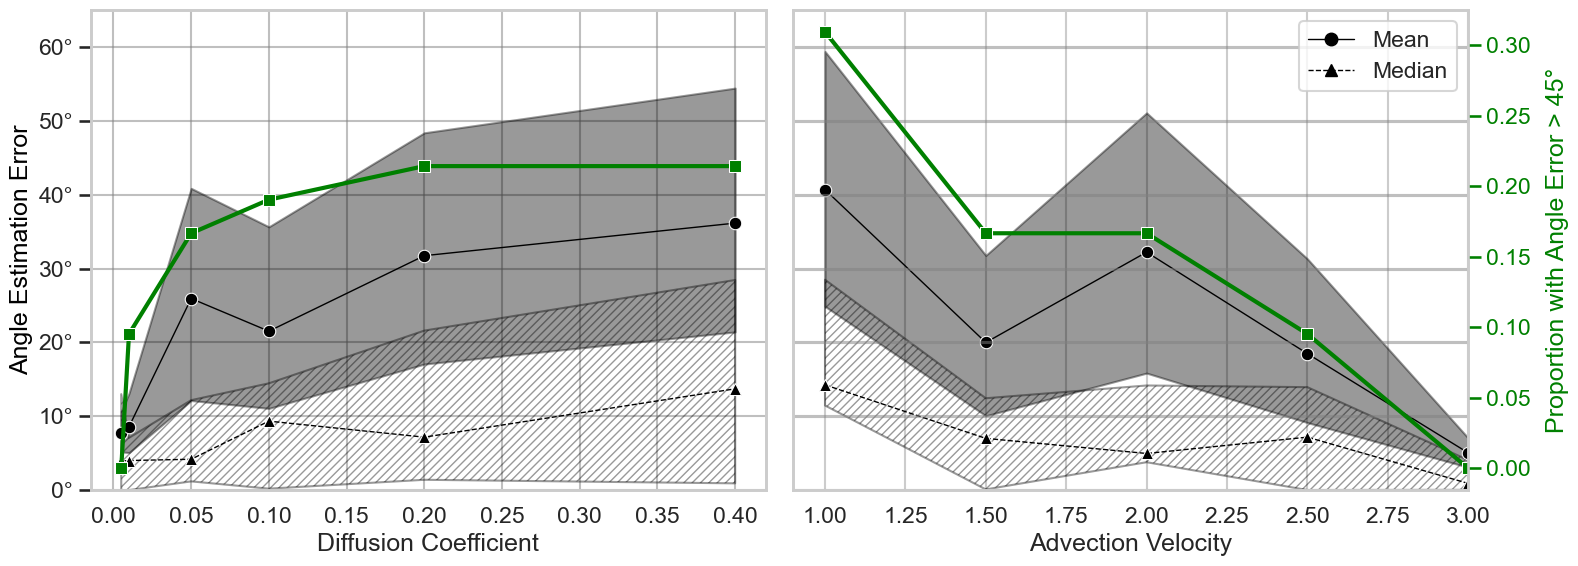

Wrote: figures/figure4_angle_estimation.pdf


In [2]:
plot_data = pd.read_csv("../data/figures/angle_error2_data.csv")

plot_data["angle_error_exceeds_45"] = (plot_data["M-Stencil Angle Difference"] > 45)

diffs_to_filter = [0.005, 0.01, 0.05, 0.1, 0.2, 0.4]
vels_to_filter  = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]

plot_data = plot_data[plot_data["diff_coefs_serial"].isin(diffs_to_filter)].copy()
plot_data = plot_data[plot_data["velocity_magnitude"].isin(vels_to_filter)].copy()

sns.set_theme(style="whitegrid", context="talk")

fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: diffusion coefficient
sns.lineplot(
    x="diff_coefs_serial", y="M-Stencil Angle Difference",
    data=plot_data, errorbar=("ci", 95), err_kws={"alpha": 0.4},
    ax=ax1, color="black", linewidth=1, marker="o",
)
sns.lineplot(
    x="diff_coefs_serial", y="M-Stencil Angle Difference",
    data=plot_data, estimator=np.median, errorbar=("ci", 95),
    err_kws={"facecolor": "none", "edgecolor": "black", "hatch": "////", "alpha": 0.4},
    ax=ax1, color="black", linewidth=1, marker="^", linestyle="--",
)

ax1.set_xlabel("Diffusion Coefficient")
ax1.set_ylabel("Angle Estimation Error", color="black")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}\u00b0"))
ax1.set_ylim(0, 65)
yticks = [0, 10, 20, 30, 40, 50, 60]
ax1.set_yticks(yticks)
ax1.grid(color="grey", linestyle="-", alpha=0.5)

ax2 = ax1.twinx()
sns.lineplot(
    x="diff_coefs_serial", y="angle_error_exceeds_45",
    data=plot_data, estimator="mean", errorbar=None,
    ax=ax2, color="green", linewidth=3, marker="s",
)
ax2.set_ylabel("")
ax2.set_yticks([])
ax2.grid(False)

# Right panel: advection velocity
right_panel_data = plot_data[plot_data["velocity_magnitude"] <= 3.0].copy()

sns.lineplot(
    x="velocity_magnitude", y="M-Stencil Angle Difference",
    data=right_panel_data, errorbar=("ci", 95), err_kws={"alpha": 0.4},
    ax=ax3, color="black", linewidth=1, marker="o",
)
sns.lineplot(
    x="velocity_magnitude", y="M-Stencil Angle Difference",
    data=right_panel_data, estimator=np.median, errorbar=("ci", 95),
    err_kws={"facecolor": "none", "edgecolor": "black", "hatch": "////", "alpha": 0.4},
    ax=ax3, color="black", linewidth=1, marker="^", linestyle="--",
)

ax3.set_xlabel("Advection Velocity")
ax3.set_ylabel("")
ax3.set_ylim(0, 65)
ax3.set_yticks([])
ax3.set_xlim(right=3.0)
for y in yticks:
    ax3.axhline(y=y, color="grey", linestyle="-", alpha=0.5)

ax4 = ax3.twinx()
sns.lineplot(
    x="velocity_magnitude", y="angle_error_exceeds_45",
    data=right_panel_data, estimator="mean", errorbar=None,
    ax=ax4, color="green", linewidth=3, marker="s",
)
ax4.set_ylabel("Proportion with Angle Error > 45\u00b0", color="green")
ax4.tick_params(axis="y", colors="green")
ax4.yaxis.set_label_coords(1.115, 0.5)
ax4.grid(False)
ax4.set_xlim(ax3.get_xlim())

custom_handles = [
    Line2D([], [], color="black", lw=1, marker="o", linestyle="-",  label="Mean"),
    Line2D([], [], color="black", lw=1, marker="^", linestyle="--", label="Median"),
]
ax3.legend(handles=custom_handles, loc="upper right", frameon=True)

ax2.set_ylim(ax4.get_ylim())

plt.tight_layout()
plt.savefig(figures_dir / "figure4_angle_estimation.pdf", bbox_inches="tight")
plt.savefig(figures_dir / "figure4_angle_estimation.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Wrote: {figures_dir / 'figure4_angle_estimation.pdf'}")

## Figure 10: ADR Ground-Truth Reaction Graph

Two-species ADR system: $u_1$ and $u_2$ react with rates defining the edges below.

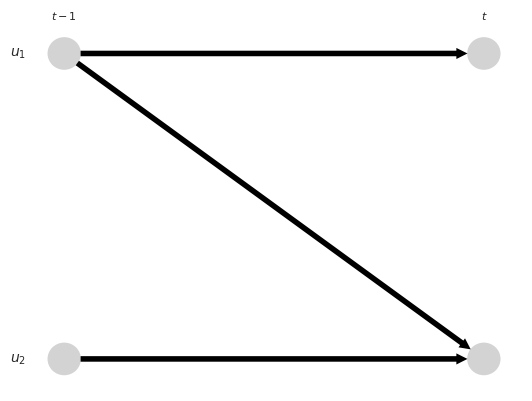

Wrote: figures/figure10_adr_reaction_graph.pdf


In [3]:
import tigramite.plotting as tp

ground_truth_reaction_graph = np.array(
    [[["" , "-->"], ["", "-->"]], [["" , ""], ["", "-->"]]], dtype=object
)
tp.plot_time_series_graph(
    ground_truth_reaction_graph,
    var_names=[r"$u_1$", r"$u_2$"],
)
plt.savefig(figures_dir / "figure10_adr_reaction_graph.pdf", bbox_inches="tight")
plt.savefig(figures_dir / "figure10_adr_reaction_graph.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Wrote: {figures_dir / 'figure10_adr_reaction_graph.pdf'}")

## Figure 11: ADR Reaction Graph F1 Distribution

Total N = 210


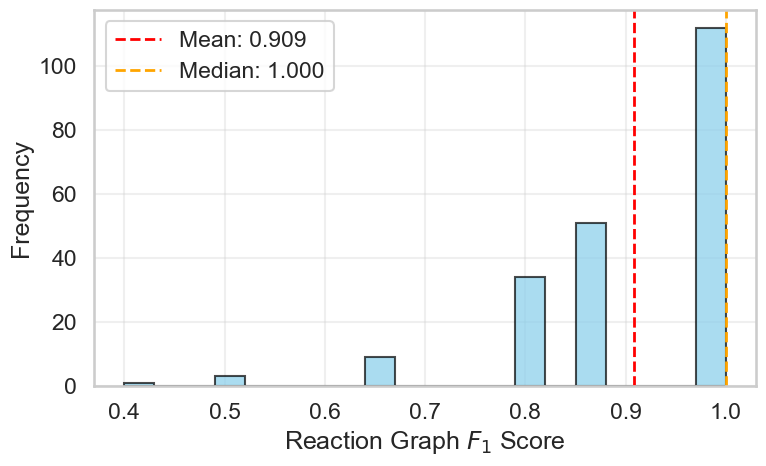

Wrote: figures/figure11_adr_f1_histogram.pdf


In [4]:
f1_data = pd.read_csv("../data/figures/adr_reaction_f1_data.csv")
f1_scores = f1_data["Reaction Graph F1"].dropna()

print(f"Total N = {len(f1_scores)}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(f1_scores, bins=20, alpha=0.7, color="skyblue", edgecolor="black")
ax.axvline(
    f1_scores.mean(), color="red", linestyle="--", linewidth=2,
    label=f"Mean: {f1_scores.mean():.3f}",
)
ax.axvline(
    f1_scores.median(), color="orange", linestyle="--", linewidth=2,
    label=f"Median: {f1_scores.median():.3f}",
)
ax.set_xlabel(r"Reaction Graph $F_1$ Score")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "figure11_adr_f1_histogram.pdf", bbox_inches="tight")
plt.savefig(figures_dir / "figure11_adr_f1_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Wrote: {figures_dir / 'figure11_adr_f1_histogram.pdf'}")